In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries ready!")

Libraries ready!


In [2]:
X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Data loaded successfully!
X_train shape: (22793, 30)
X_test shape:  (5699, 30)


In [3]:
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0173,
    random_state=42,
    verbose=1
)

isolation_forest.fit(X_train)
print("Isolation Forest trained successfully!")

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


Isolation Forest trained successfully!


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [4]:
y_pred = isolation_forest.predict(X_test)

# Isolation Forest returns 1 for normal and -1 for anomaly
# We need to convert: -1 → 1 (fraud) and 1 → 0 (normal)
y_pred = [1 if x == -1 else 0 for x in y_pred]

print("Predictions done!")
print(f"Predicted Normal:    {y_pred.count(0):,}")
print(f"Predicted Fraud:     {y_pred.count(1):,}")
print(f"Actual Fraud:        {int(y_test.sum()):,}")

Predictions done!
Predicted Normal:    5,600
Predicted Fraud:     99
Actual Fraud:        98


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5601
       Fraud       0.99      1.00      0.99        98

    accuracy                           1.00      5699
   macro avg       0.99      1.00      1.00      5699
weighted avg       1.00      1.00      1.00      5699



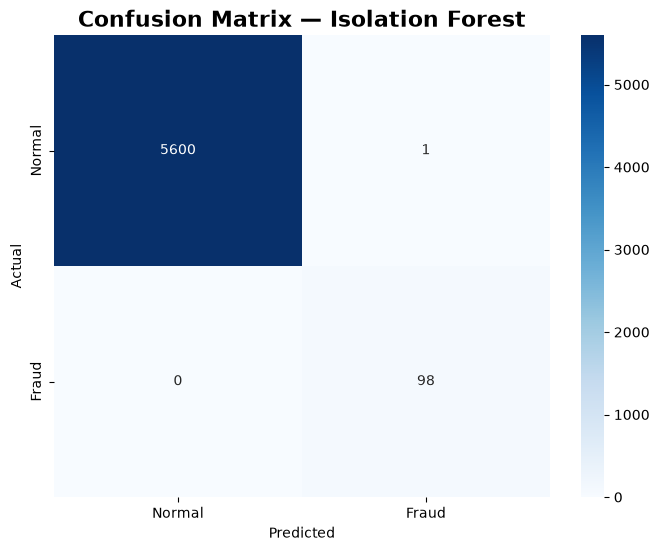

In [5]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Isolation Forest', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [6]:
import joblib

joblib.dump(isolation_forest, '../models/isolation_forest.pkl')
print("Model saved successfully!")

Model saved successfully!


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build autoencoder architecture
input_dim = X_train.shape[1]  # 30 features

# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dense(8, activation='relu')(encoder)

# Decoder
decoder = Dense(16, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

# Combine
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

print(autoencoder.summary())

ModuleNotFoundError: No module named 'tensorflow'

In [8]:
import torch
print(f"PyTorch version: {torch.__version__}")

import keras
print(f"Keras version: {keras.__version__}")

PyTorch version: 2.13.0+cpu


ModuleNotFoundError: No module named 'tensorflow'

In [9]:
from sklearn.neural_network import MLPRegressor

# Train only on normal transactions
X_train_normal = X_train[y_train == 0]

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),
    activation='relu',
    random_state=42,
    max_iter=100,
    verbose=True
)

autoencoder.fit(X_train_normal, X_train_normal)
print("Autoencoder trained successfully!")

Iteration 1, loss = 0.42890164
Iteration 2, loss = 0.38295569
Iteration 3, loss = 0.35298686
Iteration 4, loss = 0.33105966
Iteration 5, loss = 0.31871435
Iteration 6, loss = 0.31372506
Iteration 7, loss = 0.31050640
Iteration 8, loss = 0.30819866
Iteration 9, loss = 0.30648551
Iteration 10, loss = 0.30520677
Iteration 11, loss = 0.30417322
Iteration 12, loss = 0.30338631
Iteration 13, loss = 0.30272291
Iteration 14, loss = 0.30202520
Iteration 15, loss = 0.30127410
Iteration 16, loss = 0.30072461
Iteration 17, loss = 0.30036868
Iteration 18, loss = 0.30003763
Iteration 19, loss = 0.29979790
Iteration 20, loss = 0.29963678
Iteration 21, loss = 0.29940740
Iteration 22, loss = 0.29916746
Iteration 23, loss = 0.29892819
Iteration 24, loss = 0.29850890
Iteration 25, loss = 0.29798562
Iteration 26, loss = 0.29750698
Iteration 27, loss = 0.29700215
Iteration 28, loss = 0.29661944
Iteration 29, loss = 0.29630669
Iteration 30, loss = 0.29611019
Iteration 31, loss = 0.29599076
Iteration 32, los

In [10]:
# Reconstruct transactions
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction error
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# Set threshold - anything above this is fraud
threshold = np.percentile(mse, 97)
y_pred_autoencoder = (mse > threshold).astype(int)

print(f"Threshold set at: {threshold:.4f}")
print(f"Predicted Normal: {(y_pred_autoencoder == 0).sum():,}")
print(f"Predicted Fraud:  {(y_pred_autoencoder == 1).sum():,}")
print(f"Actual Fraud:     {int(y_test.sum()):,}")

Threshold set at: 1.0717
Predicted Normal: 5,528
Predicted Fraud:  171
Actual Fraud:     98


Autoencoder Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      5601
       Fraud       0.57      1.00      0.73        98

    accuracy                           0.99      5699
   macro avg       0.79      0.99      0.86      5699
weighted avg       0.99      0.99      0.99      5699



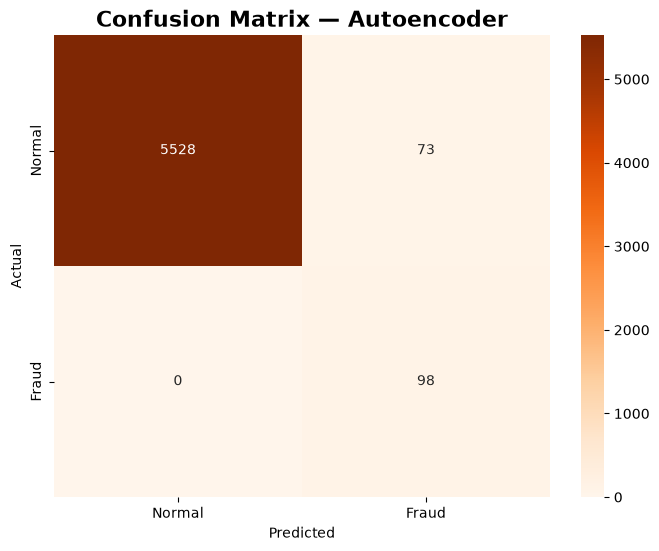

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Autoencoder Classification Report:")
print(classification_report(y_test, y_pred_autoencoder, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_autoencoder)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix — Autoencoder', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
import joblib

joblib.dump(autoencoder, '../models/autoencoder.pkl')
print("Autoencoder model saved successfully!")

Autoencoder model saved successfully!
